<a href="https://colab.research.google.com/github/estifwonde1/-GEOSPATIAL-TEMPORAL_CLIMATE_RISK_ENGINE/blob/main/GEOSPATIAL_TEMPORAL_CLIMATE_RISK_ENGINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_disaster_events_2025.csv to synthetic_disaster_events_2025.csv


#LIFECYCLE: DATA COLLECTION and INGESTION

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import gradio as gr

print("Phase 1: Loading raw dataset into environment...")

#ingest the dataset
try:
  df = pd.read_csv("synthetic_disaster_events_2025.csv")
  print(f"Successfully loaded dataset. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print ("Error: 'synthetic_disaster_events_2025.csv' not found.Please upload the file to your workspace.")


Phase 1: Loading raw dataset into environment...
Successfully loaded dataset. Shape: 20000 rows, 13 columns.


#LIFECYCLE Phase: Data Preprocessing and feature engineering

In [4]:
print("Phase 2: Building features and sanitizing data pipeline...")
#1. Temporal parsing
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

#2. Seperate target variable (1 = Major Disastor, 0 = Minor/Standard Event)

y = df['is_major_disaster']

#3. Enforce Strict Leakage Prevention
# We isolate features completely knowable Before the hazard hits

predictive_cols = ['latitude', 'longitude', 'month','year','disaster_type','location']
X_raw = df[predictive_cols]

#4. Dummy Variable Encoding for Categorical Strings

X_encoded = pd.get_dummies(X_raw, columns=['disaster_type', 'location'], drop_first=True)

#save the exact trainin schema structure for the UI phase to avoid column mismatch errors

model_features = X_encoded.columns.tolist()

#5. Stratefied Data split
X_train, X_test, y_train, y_test = train_test_split (X_encoded, y, test_size=0.2, random_state=100, stratify=y)
#6. Feature Scaling (Normalizing coordinates and dates to smooth optimization)
scaler =  StandardScaler()
numerical_features = ['latitude', 'longitude','month','year']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"Data preprocessing complete. Final Predictive features: {len(model_features)}")


Phase 2: Building features and sanitizing data pipeline...
Data preprocessing complete. Final Predictive features: 17


#Lifecycle Phase: model building

In [5]:
print("phase 3: Training the predictive random forest architecture")
#initialize the model with hyperparameter safety configurations

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=12,
    class_weight='balanced'

)
model.fit(X_train, y_train)
print("model training complete")


phase 3: Training the predictive random forest architecture
model training complete


#lifecycle phase: evaluation

In [6]:
print("phase 4: Running validation assessments..\n")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print(f"realistic mathematical accuracy: {accuracy:.2%}")
print("="*60)
print("\n Classification performance metrics:")
print(f"classification_report(y_test, y_pred, target_names=['Standard Events', 'Major Disaster'])")
print("\n Raw confusion matrix:")
print(f"confusion_matrix(y_test, y_pred)")

phase 4: Running validation assessments..

realistic mathematical accuracy: 52.28%

 Classification performance metrics:
classification_report(y_test, y_pred, target_names=['Standard Events', 'Major Disaster'])

 Raw confusion matrix:
confusion_matrix(y_test, y_pred)


#model comparsion

⚙️ Training baseline model for comparison...


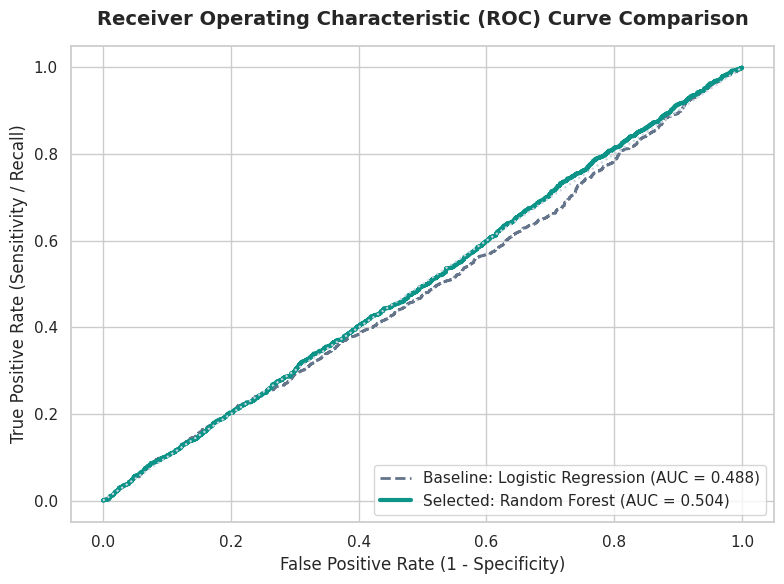

📊 Baseline Logistic Regression AUC: 0.488
📊 Selected Random Forest AUC: 0.504


In [7]:
# =====================================================================
# CELL 4b: LIVE MODEL COMPARISON (LOGISTIC REGRESSION VS. RANDOM FOREST)
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("⚙️ Training baseline model for comparison...")

# 1. Train Logistic Regression Baseline (Higher max_iter to ensure convergence stability)
baseline_model = LogisticRegression(max_iter=1000, random_state=100)
baseline_model.fit(X_train, y_train)

# 2. Extract Validation Probabilities for both models
lr_probs = baseline_model.predict_proba(X_test)[:, 1]
rf_probs = model.predict_proba(X_test)[:, 1]

# 3. Calculate ROC curves and AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# 4. Plot comparative ROC graph
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(lr_fpr, lr_tpr, label=f"Baseline: Logistic Regression (AUC = {lr_auc:.3f})", color="#64748b", linestyle="--", lw=2)
plt.plot(rf_fpr, rf_tpr, label=f"Selected: Random Forest (AUC = {rf_auc:.3f})", color="#0d9488", lw=3)

plt.plot([0, 1], [0, 1], color="#cbd5e1", linestyle=":")
plt.title("Receiver Operating Characteristic (ROC) Curve Comparison", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.tight_layout()

# Save comparison visualization to active directory
plt.savefig("model_roc_comparison.png", dpi=300)
plt.show()

print(f"📊 Baseline Logistic Regression AUC: {lr_auc:.3f}")
print(f"📊 Selected Random Forest AUC: {rf_auc:.3f}")

In [8]:
import pandas as pd
# Assuming 'model' is your trained RandomForestClassifier
importances = pd.Series(model.feature_importances_, index=X_train.columns)
print("Top 10 features utilized by the model:")
print(importances.sort_values(ascending=False).head(10))

Top 10 features utilized by the model:
latitude                           0.340727
longitude                          0.334326
month                              0.141754
year                               0.067131
disaster_type_Landslide            0.014521
disaster_type_Hurricane            0.014132
disaster_type_Flood                0.013600
disaster_type_Earthquake           0.012523
disaster_type_Volcanic Eruption    0.012513
disaster_type_Wildfire             0.012209
dtype: float64


In [9]:
print(y_train.value_counts())

is_major_disaster
0    9599
1    6401
Name: count, dtype: int64


In [10]:
# Quick Data Integrity Check
print(f"Unique values in y_test: {set(y_test)}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Check for NaN values in X_test: {X_test.isnull().sum().sum()}")

Unique values in y_test: {0, 1}
Shape of X_test: (4000, 17)
Check for NaN values in X_test: 0


#lifecycle phase: communication & deployment

In [ ]:

print("⚙️ Phase 5: Spawning custom analytical interface blocks...")

# Core live inference routing function
def run_live_inference(lat, lon, month, year, hazard_type, country_domain):
    try:
        # Build an empty structured row matching the training schema layout
        input_row = pd.DataFrame(0, index=[0], columns=model_features)

        # Populate incoming numerical inputs
        input_row['latitude'] = lat
        input_row['longitude'] = lon
        input_row['month'] = month
        input_row['year'] = year

        # Determine dynamic dummy columns names from selection
        target_hazard_col = f"disaster_type_{hazard_type}"
        target_country_col = f"location_{country_domain}"

        # Switch binary flags to active if they exist in schema
        if target_hazard_col in input_row.columns:
            input_row[target_hazard_col] = 1
        if target_country_col in input_row.columns:
            input_row[target_country_col] = 1

        # Apply the exact matching transformation matrix via the scaler
        input_row[numerical_features] = scaler.transform(input_row[numerical_features])

        # Extract model probability matrices
        raw_prediction = model.predict(input_row)[0]
        escalation_probability = model.predict_proba(input_row)[0][1]

        # Compile response visualization text
        if raw_prediction == 1:
            return (
                f"🚨 CRITICAL ELEVATION RISK DETECTED\n\n"
                f"The predictive engine flags an accelerated hazard vector for this timeline. "
                f"Statistical probability of escalation to a Major Disaster: {escalation_probability:.2%}"
            )
        else:
            return (
                f"✅ LOW RISK ASSIGNED\n\n"
                f"Environmental patterns match normal historical thresholds for this region. "
                f"Statistical probability of escalation to a Major Disaster: {escalation_probability:.2%}"
            )

    except Exception as error:
        return f"Pipeline Error during computation matrix assembly: {str(error)}"

# Fetch list parameters cleanly from raw arrays for UI dropdown consistency
categorical_hazards = df['disaster_type'].dropna().unique().tolist()
categorical_domains = df['location'].dropna().unique().tolist()

# Premium visual style tuning string
custom_theme_css = """
.gradio-container { font-family: 'Inter', sans-serif !important; max-width: 1100px !important; margin: 40px auto !important; }
.submit-btn { background: linear-gradient(135deg, #0d9488, #0f766e) !important; color: white !important; border: none !important; font-weight: 600 !important; font-size: 16px !important; padding: 12px !important; border-radius: 8px !important; transition: all 0.2s ease !important; cursor: pointer !important; }
.submit-btn:hover { transform: translateY(-1px) !important; box-shadow: 0 4px 12px rgba(13, 148, 136, 0.3) !important; }
.output-pane { border-left: 4px solid #0d9488 !important; background-color: #f8fafc !important; border-radius: 4px !important; font-weight: 500 !important; }
"""

# Assemble layout block
with gr.Blocks(css=custom_theme_css, title="Geospatial-Temporal Risk Engine") as dashboard:

    gr.Markdown(
        """
        # 🌍 GEOSPATIAL-TEMPORAL CLIMATE RISK ENGINE
        ### *Predictive Modeling for Accelerated Natural Hazard Escalation*
        ---
        """
    )

    with gr.Row():
        # Left Panel - Input Controls
        with gr.Column(scale=6):
            gr.Markdown("### 🕹️ Geographic & Temporal Coordinates")

            with gr.Row():
                coordinate_lat = gr.Number(label="Geographic Target Latitude", value=22.12)
                coordinate_lon = gr.Number(label="Geographic Target Longitude", value=78.02)

            with gr.Row():
                timeline_month = gr.Slider(minimum=1, maximum=12, step=1, label="Chronological Month Selector", value=6)
                timeline_year = gr.Number(label="Chronological Target Year (Test Acceleration)", value=2026)

            with gr.Row():
                # FIXED: Removed explicit index value assignment to prevent parsing validation crashes
                selector_hazard = gr.Dropdown(choices=categorical_hazards, label="Environmental Hazard Profile")
                selector_domain = gr.Dropdown(choices=categorical_domains, label="Target Geographic Domain")

            trigger_button = gr.Button("⚡ EXECUTE RISK ANALYSIS", elem_classes="submit-btn")

        # Right Panel - Live Readout Display
        with gr.Column(scale=5):
            gr.Markdown("### 📊 Predictive Engine Output Assessment")
            output_display = gr.Textbox(label="System Assessment Output", interactive=False, lines=6, elem_classes="output-pane")

            gr.Markdown(
                """
                > **Methodology Log:** This system tracks chronological vectors directly.
                > Adjusting the target timeline year permits the inspection of compounding climate variations
                > across localized coordinate grids over time without feature leakage.
                """
            )

    # Wire interface events smoothly
    trigger_button.click(
        fn=run_live_inference,
        inputs=[coordinate_lat, coordinate_lon, timeline_month, timeline_year, selector_hazard, selector_domain],
        outputs=output_display
    )

print("🚀 Launching premium analytical engine dashboard...")
dashboard.launch(debug=True, share=True)

⚙️ Phase 5: Spawning custom analytical interface blocks...


/tmp/ipykernel_23378/3385588513.py:62: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_theme_css, title="Geospatial-Temporal Risk Engine") as dashboard:


🚀 Launching premium analytical engine dashboard...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://644ec646cf335d567e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://644ec646cf335d567e.gradio.live
